# Preprocessing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Loadiing the dataset

bsp = pd.read_csv("bsp_speech_dataset.csv") # from 1998 to march 3, 2020
bsp.info()
bsp.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 684 entries, 0 to 683
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Title     684 non-null    object
 1   Date      684 non-null    object
 2   Location  650 non-null    object
 3   Occasion  665 non-null    object
 4   Speaker   684 non-null    object
 5   Text      684 non-null    object
 6   Len       684 non-null    int64 
 7   Link      684 non-null    object
dtypes: int64(1), object(7)
memory usage: 42.9+ KB


,Title,Date,Location,Occasion,Speaker,Text,Len,Link
0,Staying on Track in 2020: Sustaining Positive ...,03-03-2020,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,"BSP Governor Benjamin E. Diokno, Ph.D.","The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...
1,Finding Opportunities in a Borderless World,28-02-2020,"El Nido, Palawan",13th Annual FMAP Convention,"BSP Governor Benjamin E. Diokno, Ph.D.",To the officers and members of the Fund Manage...,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...
2,Gearing up for the Road Ahead: With Foresight ...,27-02-2020,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,"BSP Governor Benjamin E. Diokno, Ph.D.",Officers and members of the Professional Insur...,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...
3,A Strong Nation Amid A Slowing and Volatile World,06-02-2020,"Shangri-La at the Fort, Taguig",General Membership Meeting and Economic Briefing,"BSP Governor Benjamin E. Diokno, Ph.D.",Officers and members of the Management Associa...,2177,https://www.bsp.gov.ph/SitePages/MediaAndResea...
4,Welcome Dinner Remarks,31-01-2020,Philippine International Convenion Center,BSP-BI Bilateral Meeting,"BSP Governor Benjamin E. Diokno, Ph.D.","Governor Perry, Deputy Governors, colleagues f...",357,https://www.bsp.gov.ph/SitePages/MediaAndResea...
5,Accounting as the Language of Business: Some P...,30-01-2020,"Century Park Sheraton, Manila",First National Summit of CPAs in Commerce and ...,"BSP Governor Benjamin E. Diokno, Ph.D.",The Philippine Institute of Certified Public A...,3674,https://www.bsp.gov.ph/SitePages/MediaAndResea...
6,The Philippine Economy: Towards a More Inclusi...,28-01-2020,"V&A Law Center, Bonifacio Global City","""Financial Paradigm Shift: FinTech and the Fut...","BSP Governor Benjamin E. Diokno, Ph.D.","Ladies and gentlemen, good afternoon. I am hon...",2660,https://www.bsp.gov.ph/SitePages/MediaAndResea...
7,"A Good 2019, A Better 2020",24-01-2020,"Assembly Hall, BSP",Annual Reception for the Banking Community,"BSP Governor Benjamin E. Diokno, Ph.D.","Ladies and gentlemen, friends from the banking...",1437,https://www.bsp.gov.ph/SitePages/MediaAndResea...
8,Opening Remarks,21-01-2020,OPENING REMARKS AMLC and Philippine Amusement ...,MOA Signing,"BSP Governor Benjamin E. Diokno, Ph.D.","Ms. Andrea D. Domingo, Chairperson and Chief E...",690,https://www.bsp.gov.ph/SitePages/MediaAndResea...
9,"The Philippine Economy in 2020: Looking Back,...",09-01-2020,NaN,Rotary Club of Manila General Assembly,"BSP Governor Benjamin E. Diokno, Ph.D.",On behalf of the Bangko Sentral ng Pilipinas (...,3293,https://www.bsp.gov.ph/SitePages/MediaAndResea...


In [3]:
# Checking the number of null values for each column

nan_counts = bsp.isna().sum()
nan_counts

,0
Title,0
Date,0
Location,34
Occasion,19
Speaker,0
Text,0
Len,0
Link,0


In [4]:
print("Rows with missing values:")
bsp[bsp.isnull().any(axis=1)]

Rows with missing values:


,Title,Date,Location,Occasion,Speaker,Text,Len,Link
9,"The Philippine Economy in 2020: Looking Back,...",09-01-2020,NaN,Rotary Club of Manila General Assembly,"BSP Governor Benjamin E. Diokno, Ph.D.",On behalf of the Bangko Sentral ng Pilipinas (...,3293,https://www.bsp.gov.ph/SitePages/MediaAndResea...
35,Opening Remarks,02-09-2019,NaN,Signing of Memorandum of Understanding between...,"BSP Governor Benjamin E. Diokno, Ph.D.","Prof. Ramayya Krishnan, Dean, Heinz College of...",538,https://www.bsp.gov.ph/SitePages/MediaAndResea...
36,The PH Economy: Sustaining Resilience Amid Unc...,27-08-2019,NaN,Economic Journalists? Association of the Phili...,"BSP Governor Benjamin E. Diokno, Ph.D.","Good morning, ladies and gentlemen. First, let...",1831,https://www.bsp.gov.ph/SitePages/MediaAndResea...
39,The Road to Financial Inclusion and Sustainabl...,16-08-2019,NaN,"Philippine Exporters Confederation, Inc. (PHIL...","BSP Governor Benjamin E. Diokno, Ph.D.","To Chairman Paterno Dizon, Dr. Sergio Ortiz-Lu...",2195,https://www.bsp.gov.ph/SitePages/MediaAndResea...
40,Philippines: Weaving an Unprecedented Growth S...,06-08-2019,NaN,Ayala Economic and Treasury Summit,"BSP Governor Benjamin E. Diokno, Ph.D.","Jaime, Fernando, other senior Ayala officials,...",2733,https://www.bsp.gov.ph/SitePages/MediaAndResea...
48,Sustained Partnerships in Financial Inclusion,18-06-2019,NaN,CMA Press Launch,Gov. Benjamin E. Diokno,"To my colleagues from BSP, partners from the M...",847,https://www.bsp.gov.ph/SitePages/MediaAndResea...
50,Sustaining the Philippine Growth Momentum,06-06-2019,NaN,Rotary Club of Manila Centennial Year,Governor Benjamin E. Diokno,"President Susing Pineda, fellow rotarians, fri...",2209,https://www.bsp.gov.ph/SitePages/MediaAndResea...
51,Ensuring Price Stability through Monetary Policy,17-05-2019,NaN,Breakfast Briefing with the Italian Chamber of...,Governor Benjamin E. Diokno,To the officers and members of the Italian Cha...,1780,https://www.bsp.gov.ph/SitePages/MediaAndResea...
139,Lessons from the Philippines: Financial stabil...,29-06-2017,NaN,NaN,"BSP Governor Amando M. Tetangco, Jr",Read Article,2,https://www.bsp.gov.ph/SitePages/MediaAndResea...
147,Learning from Instabilities to Build a Better ...,23-03-2017,NaN,Testimonial Dinner hosted by the PDS Group,"BSP Governor Amando M. Tetangco, Jr.",I am deeply honored and am very grateful to th...,1279,https://www.bsp.gov.ph/SitePages/MediaAndResea...


In [5]:
# Replacing missing values with "unknown"

bsp.fillna("unknown", inplace=True)

print("Rows with 'unknown' value after replacement:")
bsp[bsp.eq("unknown").any(axis=1)]

Rows with 'unknown' value after replacement:


,Title,Date,Location,Occasion,Speaker,Text,Len,Link
9,"The Philippine Economy in 2020: Looking Back,...",09-01-2020,unknown,Rotary Club of Manila General Assembly,"BSP Governor Benjamin E. Diokno, Ph.D.",On behalf of the Bangko Sentral ng Pilipinas (...,3293,https://www.bsp.gov.ph/SitePages/MediaAndResea...
35,Opening Remarks,02-09-2019,unknown,Signing of Memorandum of Understanding between...,"BSP Governor Benjamin E. Diokno, Ph.D.","Prof. Ramayya Krishnan, Dean, Heinz College of...",538,https://www.bsp.gov.ph/SitePages/MediaAndResea...
36,The PH Economy: Sustaining Resilience Amid Unc...,27-08-2019,unknown,Economic Journalists? Association of the Phili...,"BSP Governor Benjamin E. Diokno, Ph.D.","Good morning, ladies and gentlemen. First, let...",1831,https://www.bsp.gov.ph/SitePages/MediaAndResea...
39,The Road to Financial Inclusion and Sustainabl...,16-08-2019,unknown,"Philippine Exporters Confederation, Inc. (PHIL...","BSP Governor Benjamin E. Diokno, Ph.D.","To Chairman Paterno Dizon, Dr. Sergio Ortiz-Lu...",2195,https://www.bsp.gov.ph/SitePages/MediaAndResea...
40,Philippines: Weaving an Unprecedented Growth S...,06-08-2019,unknown,Ayala Economic and Treasury Summit,"BSP Governor Benjamin E. Diokno, Ph.D.","Jaime, Fernando, other senior Ayala officials,...",2733,https://www.bsp.gov.ph/SitePages/MediaAndResea...
48,Sustained Partnerships in Financial Inclusion,18-06-2019,unknown,CMA Press Launch,Gov. Benjamin E. Diokno,"To my colleagues from BSP, partners from the M...",847,https://www.bsp.gov.ph/SitePages/MediaAndResea...
50,Sustaining the Philippine Growth Momentum,06-06-2019,unknown,Rotary Club of Manila Centennial Year,Governor Benjamin E. Diokno,"President Susing Pineda, fellow rotarians, fri...",2209,https://www.bsp.gov.ph/SitePages/MediaAndResea...
51,Ensuring Price Stability through Monetary Policy,17-05-2019,unknown,Breakfast Briefing with the Italian Chamber of...,Governor Benjamin E. Diokno,To the officers and members of the Italian Cha...,1780,https://www.bsp.gov.ph/SitePages/MediaAndResea...
139,Lessons from the Philippines: Financial stabil...,29-06-2017,unknown,unknown,"BSP Governor Amando M. Tetangco, Jr",Read Article,2,https://www.bsp.gov.ph/SitePages/MediaAndResea...
147,Learning from Instabilities to Build a Better ...,23-03-2017,unknown,Testimonial Dinner hosted by the PDS Group,"BSP Governor Amando M. Tetangco, Jr.",I am deeply honored and am very grateful to th...,1279,https://www.bsp.gov.ph/SitePages/MediaAndResea...


In [6]:
# Checking the unique values of the 'Speaker' column

bsp['Speaker'].unique()

array(['BSP Governor Benjamin E. Diokno, Ph.D.',
       'Governor Benjamin E. Diokno', 'BSP Governor Benjamin E. Diokno',
       'Gov. Benjamin E. Diokno', 'BSP Governor Benjamin Diokno',
       'Former BSP Governor Amando M. Tetangco Jr.',
       'BSP OIC Maria Almasara Cyd N. Tuano-Amador',
       'BSP Governor Nestor A. Espenilla, Jr., as delivered by BSP Deputy Governor Chuchi G. Fonacier',
       'Governor Nestor A. Espenilla, Jr. delivered by Officer-in-Charge Chuchi G. Fonacier',
       'Governor Nestor A. Espenilla, Jr., as delivered by Deputy Governor Diwa C. Guinigundo',
       'BSP Governor Nestor A. Espenilla, Jr., as delivered by Deputy Governor Chuchi G. Fonacier,',
       'Governor Nestor A. Espenilla, Jr., as delivered by MBM Peter B. Favila',
       'Governor Nestor A. Espenilla, Jr. delivered by Deputy Governor Maria Almasara Cyd N. Tuano-Amador',
       'Deputy Governor Chuchi G. Fonancier, FSS on behalf of Governor Nestor A. Espenilla, Jr.',
       'BSP Governor Nes

In [7]:
# Cleaning the values of the 'Speaker' column

bsp['Speaker'] = bsp['Speaker'].str.replace(", Jr.", "")
bsp['Speaker'] = bsp['Speaker'].str.replace(", Ph.D", "")
bsp['Speaker'] = bsp['Speaker'].str.replace("Ph.D", "")
bsp['Speaker'] = bsp['Speaker'].str.replace(", Jr", "")
bsp['Speaker'] = bsp['Speaker'].str.replace(" Jr.", "")
bsp['Speaker'] = bsp['Speaker'].str.replace(",Jr.", "")
bsp['Speaker'] = bsp['Speaker'].str.replace(",Jr", "")
bsp['Speaker'] = bsp['Speaker'].str.replace(", Ph.D.", "")
bsp['Speaker'] = bsp['Speaker'].str.replace(", Ph. D.", "")
bsp['Speaker'] = bsp['Speaker'].str.split('as delivered').str[0]
bsp['Speaker'] = bsp['Speaker'].str.split('delivered').str[0]
bsp['Speaker'] = bsp['Speaker'].str.replace('Tetangco,', 'Tetangco', regex=False)
bsp['Speaker'] = bsp['Speaker'].str.replace('Espenilla,', 'Espenilla', regex=False)
bsp['Speaker'] = bsp['Speaker'].str.replace('Diokno.', 'Diokno', regex=False)
bsp['Speaker'] = bsp['Speaker'].str.replace('Tua?o-Amador', 'Tuano-Amador', regex=False)

# Creating a new column ('last_name') to store the surnames of the speakers
bsp['last_name'] = bsp['Speaker'].str.strip().str.split(' ', expand=False).str.get(-1)

# Defining the variable 'governors' and assigning the unique values of the 'last_name' column to it
governors = bsp['last_name'].unique()
governors

array(['Diokno', 'Tetangco', 'Tuano-Amador', 'Espenilla', 'Fonacier',
       'Guinigundo', 'Buenaventura', 'Reyes', 'Singson'], dtype=object)

Note that these codes above already takes into account the speaker values with the following format:
*   "Person A, delivered/as delivered by Person B" (rows 61-66), and
*   "Person B on behalf of Person A" (rows 67,90,107).

In all those instances, we're only concerned with Person A from which the speech content came from.

It also takes into account the instance where the speaker value is "Joint message of Education Secretary Br Armin Luistro FSC and BSP Governor Amando Tetangco, Jr." (row 266)
* In this case, we're also only concerned with the BSP Governor who gave the speech.

In [8]:
bsp.groupby('last_name').size()

,0
last_name,
Buenaventura,204
Diokno,57
Espenilla,77
Fonacier,1
Guinigundo,2
Reyes,1
Singson,9
Tetangco,331
Tuano-Amador,2


In [9]:
# Extracting the year components of the 'Date' column and storing it to the new column called 'year'

bsp['Date'] = pd.to_datetime(bsp['Date'], dayfirst=True)
bsp['year'] = bsp['Date'].dt.year
bsp.head()

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
1,Finding Opportunities in a Borderless World,2020-02-28,"El Nido, Palawan",13th Annual FMAP Convention,BSP Governor Benjamin E. Diokno,To the officers and members of the Fund Manage...,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
2,Gearing up for the Road Ahead: With Foresight ...,2020-02-27,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,BSP Governor Benjamin E. Diokno,Officers and members of the Professional Insur...,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
3,A Strong Nation Amid A Slowing and Volatile World,2020-02-06,"Shangri-La at the Fort, Taguig",General Membership Meeting and Economic Briefing,BSP Governor Benjamin E. Diokno,Officers and members of the Management Associa...,2177,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
4,Welcome Dinner Remarks,2020-01-31,Philippine International Convenion Center,BSP-BI Bilateral Meeting,BSP Governor Benjamin E. Diokno,"Governor Perry, Deputy Governors, colleagues f...",357,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020


In [10]:
# Checking speeches with the same text

bsp[bsp.duplicated(subset='Text', keep=False)]

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
55,Policy Continuity and Institutional Independence,2019-03-08,BSP Executive Business Center,Press Conference,BSP Governor Benjamin E. Diokno,Good morning. I am happy to be with you all to...,922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2019
56,Policy Continuity and Institutional Independence,2019-03-08,BSP Executive Business Center,Press Conference held at the BSP Executive Bus...,Governor Benjamin E. Diokno,Good morning. I am happy to be with you all to...,922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2019
308,Moving Central Banking Forward Through the Leg...,2010-07-27,"Executive Business Center, BSP",Launching of the Legal Book on RA 7653,Governor Amando M. Tetangco,The honorable members of the judicial and the ...,737,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Tetangco,2010
310,Moving Central Banking Forward Through the Leg...,2010-07-27,"Executive Business Center, BSP",Book Launching of the Legal Book on RA 7653,Governor Amando M. Tetangco,The honorable members of the judicial and the ...,737,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Tetangco,2010
556,Strengthening Links with Our Partners at PNP,2003-01-13,"Camp Crame, Quezon City","Flag Raising Ceremony, Philippine National Police",Governor Rafael Buenaventura,Introduction Good morning ladies and gentlemen...,1791,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Buenaventura,2003
557,New Year's Message 2003,2003-01-10,"Fort San Antonio Abad, BSP Complex, Manila",Annual Reception for the Banking Community,Governor Rafael Buenaventura,"Good evening ladies and gentlemen... Tonight, ...",1019,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Buenaventura,2003
586,Keynote Address,2002-03-14,"Bangko Sentral ng Pilipinas, Manila","Annual Meeting, Philippine Economic Society",Governor Rafael Buenaventura,Introduction Good morning ladies and gentlemen...,1791,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Buenaventura,2002
587,Remarks,2002-01-11,"Bangko Sentral ng Pilipinas, Manila",Annual Reception for the Banking Community,Governor Rafael Buenaventura,"Good evening ladies and gentlemen... Tonight, ...",1019,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Buenaventura,2002


In [11]:
# After checking those speeches with the official bsp website, we drop the following:
## The second occurrence of the 2019-03-08 and 2010-07-27 speeches
## The 2003-01-10 speech as it was a duplicate of the 2002-01-11 speech
## The 2003-01-13 speech as it was a duplicate of the 2002-03-14 speech

# Drop specific rows by index
bsp.drop(index=[56, 310, 556, 557], inplace=True)

# Resetting the index
bsp.reset_index(drop=True, inplace=True)

In [12]:
# Checking speeches with the same text

bsp[bsp.duplicated(subset='Text', keep=False)]

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year


In [13]:
bsp['Len'].describe()

,Len
count,680.000000
mean,1368.011765
std,669.058880
min,2.000000
25%,808.500000
50%,1350.500000
75%,1850.500000
max,3674.000000


In [14]:
# Checking the speech with len 2

bsp[bsp['Len'] == 2]

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
138,Lessons from the Philippines: Financial stabil...,2017-06-29,unknown,unknown,BSP Governor Amando M. Tetangco,Read Article,2,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Tetangco,2017


In [15]:
bsp = bsp[bsp['Len'] != 2]

In [16]:
bsp.loc[137:139]

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
137,Continuing the Voyage of Excellence to a Brigh...,2017-07-03,"BSP Assembly Hall, BSP Complex, Manila",24th Anniversary Program of the Bangko Sentral...,Governor Nestor A. Espenilla,"Outgoing Governor Amando M. Tetangco, Jr.; dis...",2124,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Espenilla,2017
139,Financial Education and Consumer Protection: T...,2017-06-06,"Assembly Hall, BSP",Launch of Wealth Watch Book II,Governor Amando M. Tetangco,Thank you for joining us at the launching of t...,1064,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Tetangco,2017


In [17]:
# Resetting the index

bsp.reset_index(drop=True, inplace=True)

In [18]:
bsp.loc[137:139]

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
137,Continuing the Voyage of Excellence to a Brigh...,2017-07-03,"BSP Assembly Hall, BSP Complex, Manila",24th Anniversary Program of the Bangko Sentral...,Governor Nestor A. Espenilla,"Outgoing Governor Amando M. Tetangco, Jr.; dis...",2124,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Espenilla,2017
138,Financial Education and Consumer Protection: T...,2017-06-06,"Assembly Hall, BSP",Launch of Wealth Watch Book II,Governor Amando M. Tetangco,Thank you for joining us at the launching of t...,1064,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Tetangco,2017
139,"Running the Race, Fighting the Good Fight",2017-06-06,"Rizal Ballroom, Shangri-la Makati",Joint General Assembly of MART with ACI Phils....,BSP Governor Amando M. Tetangco,Twenty six (26) days. That is what my ENDO cou...,2041,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Tetangco,2017


In [19]:
bsp['Len'].describe()

,Len
count,679.000000
mean,1370.023564
std,667.490653
min,171.000000
25%,811.000000
50%,1352.000000
75%,1851.000000
max,3674.000000


In [22]:
# from studying the text speeches we saw that there are duplicate speeches that were not detected as duplicates
# this is due to small differences in the typeset of scraped texts
# the indices of these speeches are as follows:
# 29, 30, 97, 98, 99, 100

bsp.iloc[[29, 30, 97, 98, 99, 100]]

,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
29,The Philippine Economy: Sustaining Resilience ...,2019-09-24,"Fairmont Hotel, Makati",Philippines Investment Forum (Euromoney),Governor Benjamin E. Diokno,"Mr. Tony Shale, Euromoney executives, colleagu...",2414,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2019
30,The Philippine Economy: Sustaining Resilience ...,2019-09-24,"Fairmont Hotel, Makati",Philippines Investment Forum (Euromoney),BSP Governor Benjamin E. Diokno,"Mr. Tony Shale, Euromoney executives, colleagu...",2420,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2019
97,"Continuity Plus-Plus, Staying Ahead of the Curves",2018-01-19,"Fort San Antonio Abad, Bangko Sentral ng Pilip...",Annual Reception for the Banking Community,BSP Governor Nestor A. Espenilla,Good evening. It is my honor and pleasure to w...,1248,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Espenilla,2018
98,"Continuity Plus Plus, Staying Ahead of the Curves",2018-01-19,"Fort San Antonio Abad, Bangko Sentral ng Pilip...",Annual Reception for the Banking Community,Governor Nestor A. Espenilla,Good evening. It is my honor and pleasure to w...,1249,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Espenilla,2018
99,Generativity,2018-01-17,Shangri-la at The Fort,YPO event ?PH Business and Economy: Outlook an...,BSP Governor Nestor A. Espenilla,Good evening. I am very pleased to be here. I ...,1653,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Espenilla,2018
100,Generativity <sup>1</sup>,2018-01-17,Shangri-la at The Fort,YPO event ?PH Business and Economy: Outlook an...,by Governor Nestor A. Espenilla,Good evening. I am very pleased to be here. I ...,1651,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Espenilla,2018


In [23]:
# we delete speeches # 29, 97, and 100

bsp.drop(index=[29, 97, 100], inplace=True)

In [24]:
# Creating an index column

bsp['index'] = bsp.index

In [26]:
cols = bsp.columns.tolist()
cols.insert(0, cols.pop(cols.index('index')))
bsp = bsp[cols]

In [27]:
bsp.info()
bsp.head()

<class 'pandas.core.frame.DataFrame'>
Index: 676 entries, 0 to 678
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   index      676 non-null    int64         
 1   Title      676 non-null    object        
 2   Date       676 non-null    datetime64[ns]
 3   Location   676 non-null    object        
 4   Occasion   676 non-null    object        
 5   Speaker    676 non-null    object        
 6   Text       676 non-null    object        
 7   Len        676 non-null    int64         
 8   Link       676 non-null    object        
 9   last_name  676 non-null    object        
 10  year       676 non-null    int32         
dtypes: datetime64[ns](1), int32(1), int64(2), object(7)
memory usage: 60.7+ KB


,index,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
0,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
1,1,Finding Opportunities in a Borderless World,2020-02-28,"El Nido, Palawan",13th Annual FMAP Convention,BSP Governor Benjamin E. Diokno,To the officers and members of the Fund Manage...,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
2,2,Gearing up for the Road Ahead: With Foresight ...,2020-02-27,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,BSP Governor Benjamin E. Diokno,Officers and members of the Professional Insur...,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
3,3,A Strong Nation Amid A Slowing and Volatile World,2020-02-06,"Shangri-La at the Fort, Taguig",General Membership Meeting and Economic Briefing,BSP Governor Benjamin E. Diokno,Officers and members of the Management Associa...,2177,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
4,4,Welcome Dinner Remarks,2020-01-31,Philippine International Convenion Center,BSP-BI Bilateral Meeting,BSP Governor Benjamin E. Diokno,"Governor Perry, Deputy Governors, colleagues f...",357,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020


In [28]:
# Saving the updated dataset, with the additional columns, into a new csv file

bsp.to_csv('latest_bsp_speech_dataset.csv', index=False)

# EDA

In [29]:
bsp['Len'].describe()

,Len
count,676.000000
mean,1368.244083
std,667.657944
min,171.000000
25%,808.500000
50%,1350.500000
75%,1850.500000
max,3674.000000


<Axes: title={'center': 'Number of speeches by year"'}, xlabel='year'>

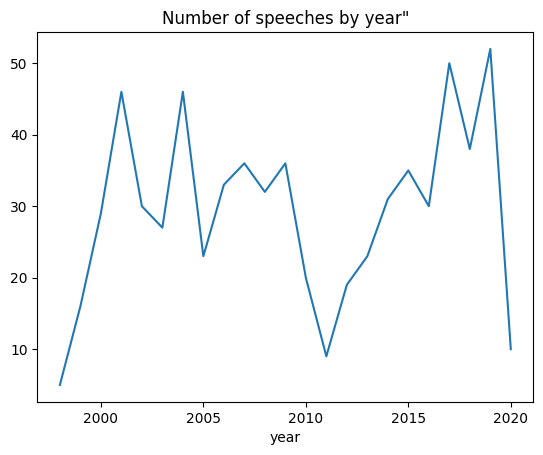

In [30]:
bsp.groupby('year').size().plot(title='Number of speeches by year"')

      last_name    N
7      Tetangco  329
0  Buenaventura  202
2     Espenilla   75
1        Diokno   55
6       Singson    9
8  Tuano-Amador    2
4    Guinigundo    2
3      Fonacier    1
5         Reyes    1


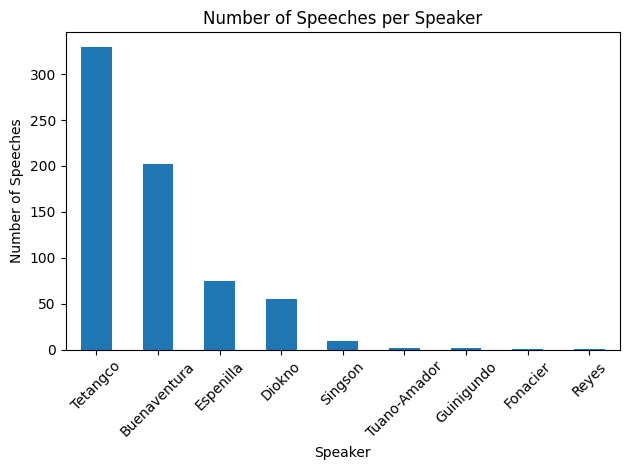

In [31]:
# Group and sort by number of speeches
speaker_counts = bsp.groupby('last_name').size().reset_index(name='N').sort_values('N', ascending=False)

# Print the values
print(speaker_counts)

# Plot
ax = speaker_counts.plot.bar(x='last_name', y='N', legend=False)

# Add title and labels
plt.title("Number of Speeches per Speaker")
plt.xlabel("Speaker")
plt.ylabel("Number of Speeches")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

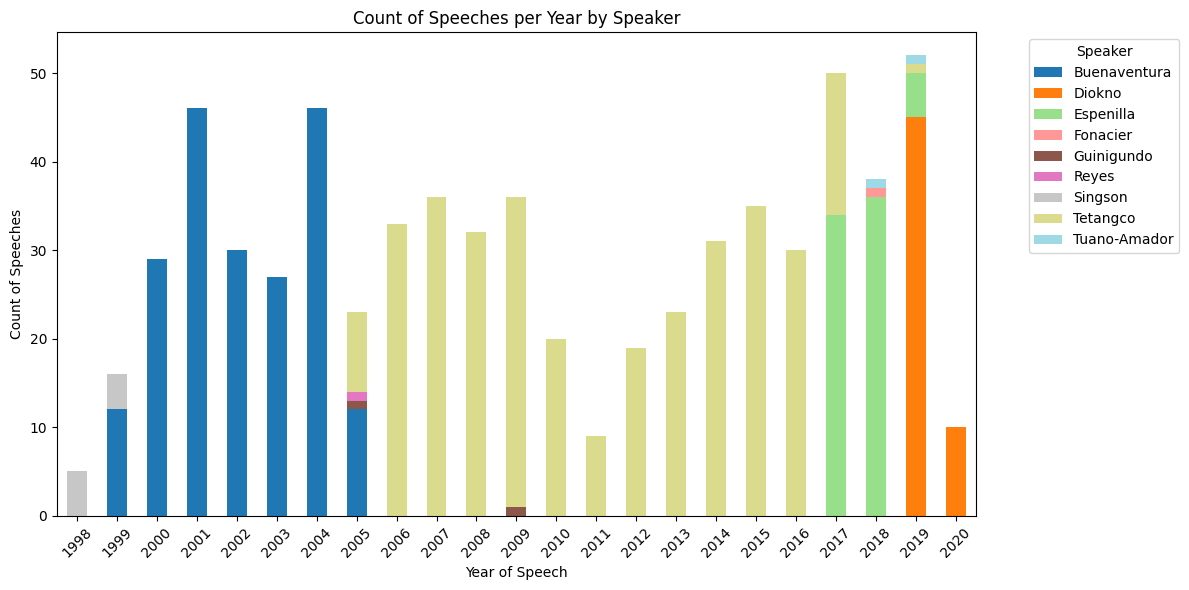

In [32]:
# Group data by year and last_name
speech_counts = bsp.groupby(['year', 'last_name']).size().reset_index(name='count')
pivot_df = speech_counts.pivot(index='year', columns='last_name', values='count').fillna(0)
pivot_df = pivot_df.sort_index(axis=1)

pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')

plt.title('Count of Speeches per Year by Speaker')
plt.xlabel('Year of Speech')
plt.ylabel('Count of Speeches')
plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

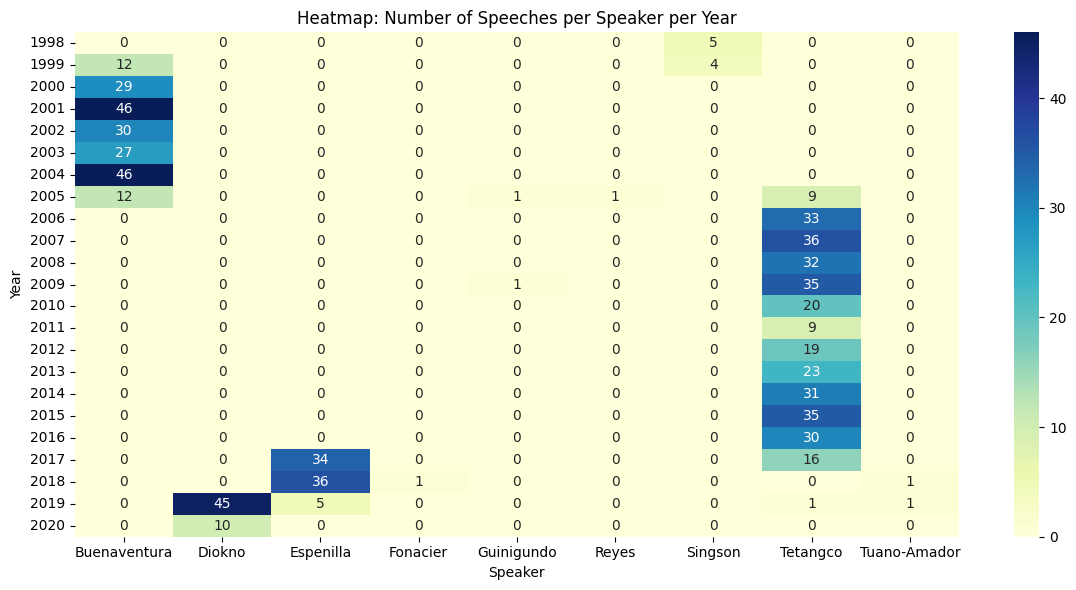

In [33]:
# Count number of speeches by year and speaker
speech_count = bsp.groupby(['year', 'last_name']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_count, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Heatmap: Number of Speeches per Speaker per Year')
plt.xlabel('Speaker')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Total Length of Speeches per Year'}, xlabel='year', ylabel='Total Length'>

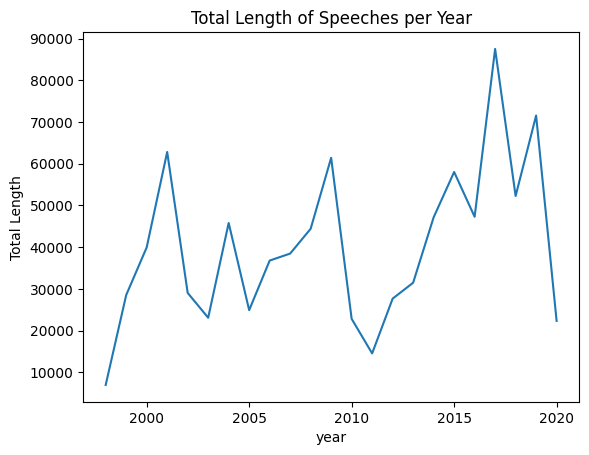

In [34]:
bsp.groupby('year')['Len'].sum().plot(title='Total Length of Speeches per Year', ylabel='Total Length')

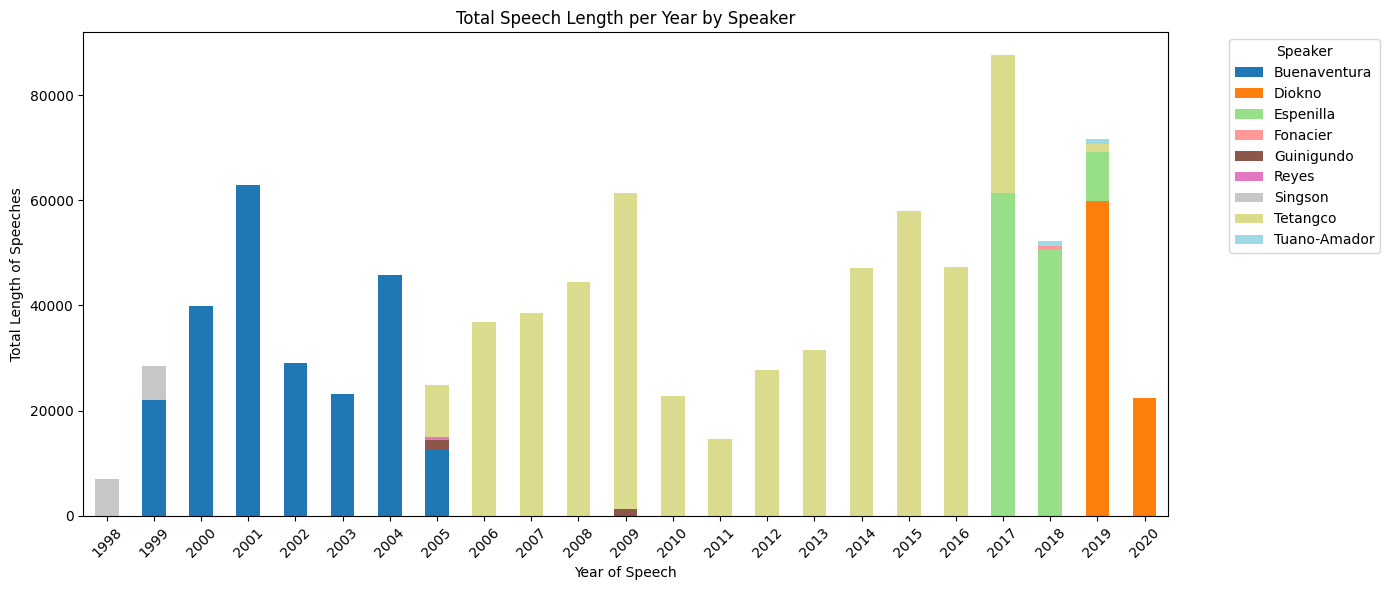

In [35]:
# Group by year and last_name, then sum 'Len' (speech length)
lengths_by_year_speaker = bsp.groupby(['year', 'last_name'])['Len'].sum().reset_index()

# Pivot: rows = year, columns = speakers, values = total length
pivot_len_df = lengths_by_year_speaker.pivot(index='year', columns='last_name', values='Len').fillna(0)

# Sort columns alphabetically (optional)
pivot_len_df = pivot_len_df.sort_index(axis=1)

# Plot
pivot_len_df.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')

plt.title('Total Speech Length per Year by Speaker')
plt.xlabel('Year of Speech')
plt.ylabel('Total Length of Speeches')
plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

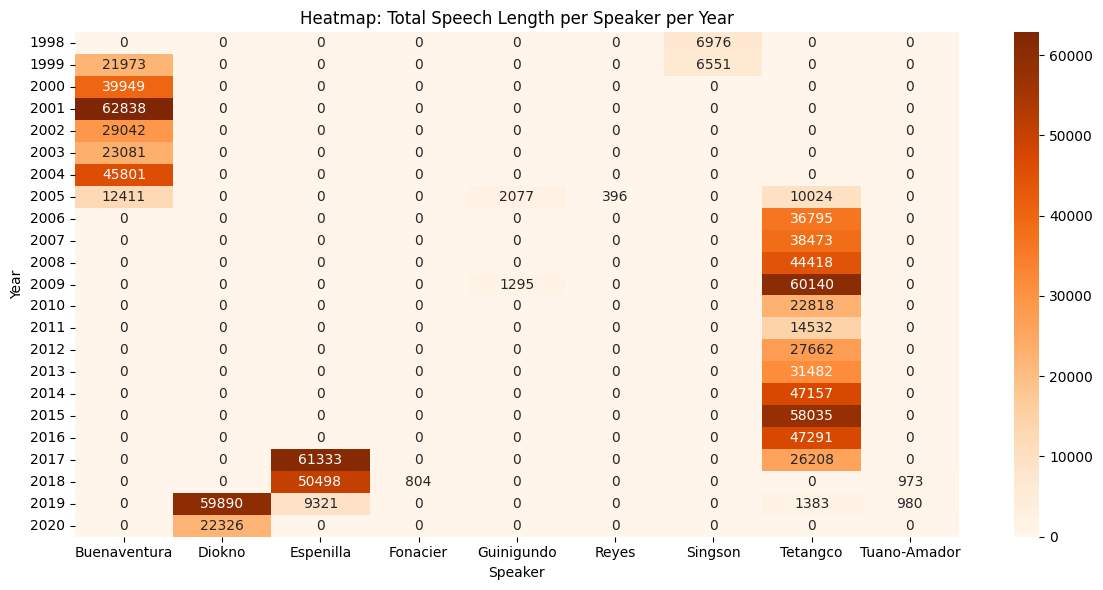

In [36]:
# Sum total speech lengths by year and speaker
speech_length = bsp.groupby(['year', 'last_name'])['Len'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_length, annot=True, fmt='.0f', cmap='Oranges')

plt.title('Heatmap: Total Speech Length per Speaker per Year')
plt.xlabel('Speaker')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

In [37]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.feature_extraction import text

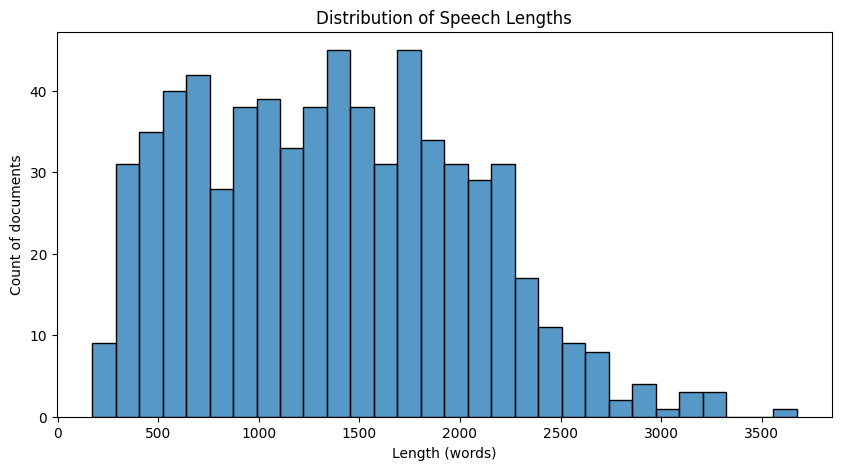

In [38]:
# Histogram of speech lengths
plt.figure(figsize=(10, 5))
sns.histplot(bsp['Len'], bins=30)
plt.xlabel("Length (words)")
plt.ylabel("Count of documents")
plt.title("Distribution of Speech Lengths")
plt.show()

/tmp/ipykernel_4003/2757900109.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bsp['month'] = bsp['Date'].dt.strftime('%b')
/tmp/ipykernel_4003/2757900109.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bsp['month'] = pd.Categorical(bsp['month'], categories=month_order, ordered=True)
/tmp/ipykernel_4003/2757900109.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

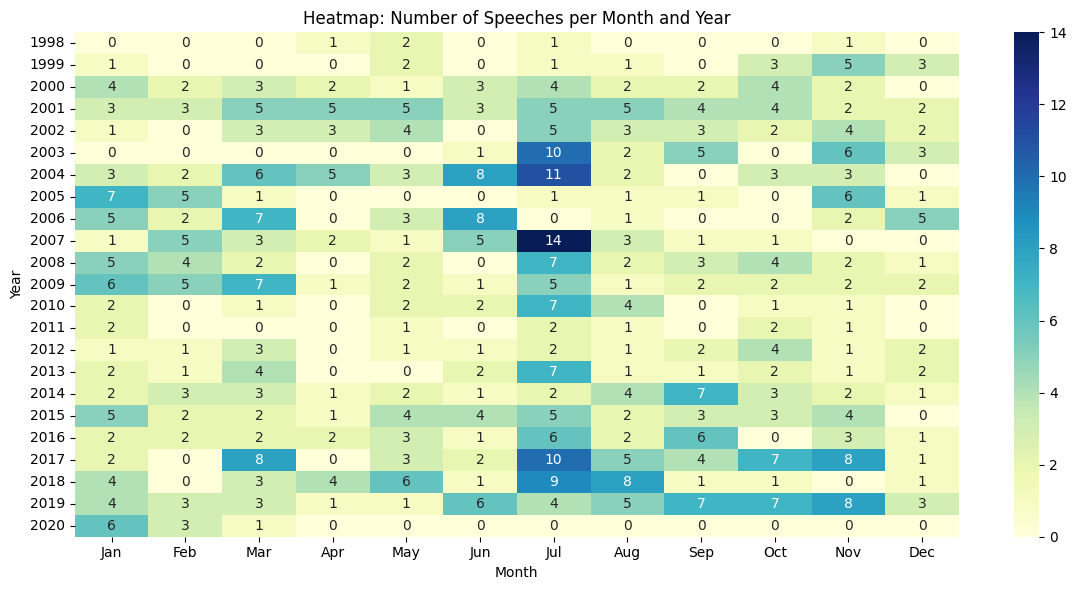

In [39]:
# Heatmap of Number of Speeches per Month and Year


# Convert numeric month to abbreviated month name (e.g., Jan, Feb)
bsp['month'] = bsp['Date'].dt.strftime('%b')

# Make month a categorical variable with the correct order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bsp['month'] = pd.Categorical(bsp['month'], categories=month_order, ordered=True)


# Count speeches by year and month
speech_count = bsp.groupby(['year', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_count, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Number of Speeches per Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4003/1211288932.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  speech_length = bsp.groupby(['year', 'month'])['Len'].sum().unstack(fill_value=0)


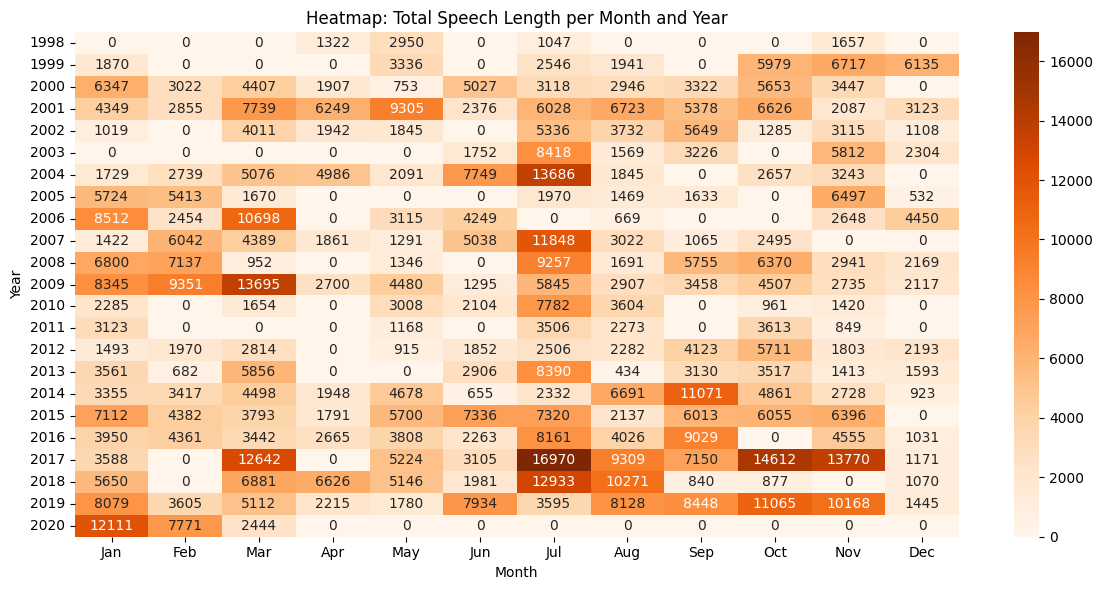

In [40]:
# Length of Speeches Heatmap
speech_length = bsp.groupby(['year', 'month'])['Len'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_length, annot=True, fmt='.0f', cmap='Oranges')
plt.title('Heatmap: Total Speech Length per Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

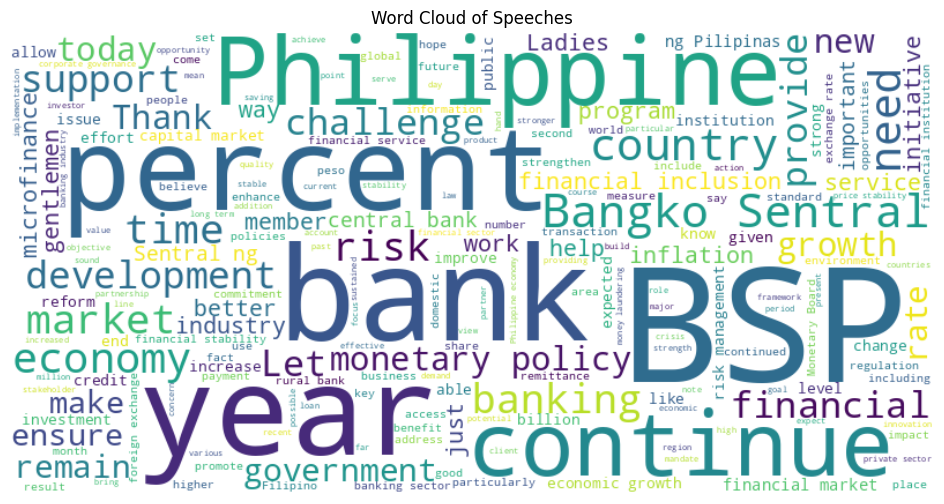

In [41]:
# Word cloud
text_combined = ' '.join(bsp['Text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      stopwords=text.ENGLISH_STOP_WORDS).generate(text_combined)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Speeches")
plt.show()

In [42]:
# TF-IDF + KMeans Clustering
vectorizer = TfidfVectorizer(max_df=0.95, min_df=5, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(bsp['Text'].dropna())
kmeans = KMeans(n_clusters=4, random_state=42)
bsp['cluster'] = np.nan
bsp.loc[bsp['Text'].notna(), 'cluster'] = kmeans.fit_predict(tfidf_matrix)

/tmp/ipykernel_4003/256480887.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bsp['cluster'] = np.nan


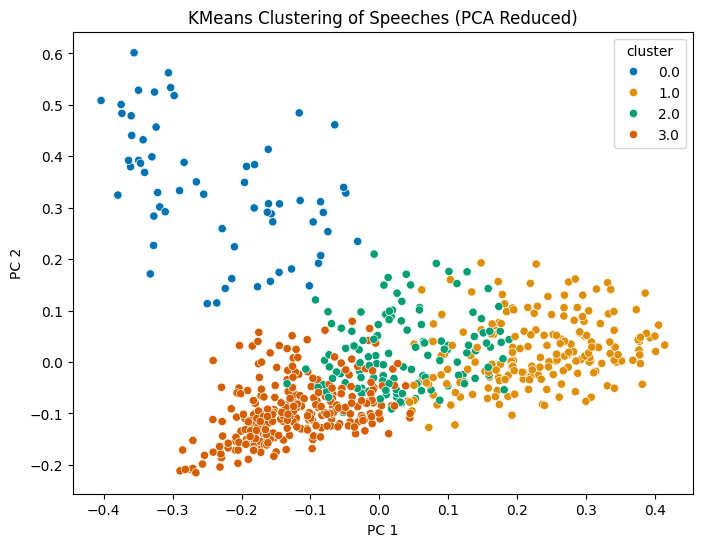

In [43]:
# To interpret KMeans visually

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=bsp.loc[bsp['Text'].notna(), 'cluster'], palette='colorblind')
plt.title('KMeans Clustering of Speeches (PCA Reduced)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

In [44]:
# Extracting top keywords per cluster

terms = vectorizer.get_feature_names_out()

# For each cluster, get top N terms
top_n = 15
for i in range(kmeans.n_clusters):
    print(f"\nCluster {i} Top Terms:")
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[::-1][:top_n]
    for idx in top_indices:
        print(f"  {terms[idx]}")


Cluster 0 Top Terms:
  microfinance
  rural
  banks
  banking
  financial
  rbap
  microentrepreneurs
  services
  cma
  clients
  poverty
  credit
  bsp
  poor
  industry

Cluster 1 Top Terms:
  percent
  inflation
  bsp
  growth
  financial
  policy
  market
  economy
  economic
  monetary
  year
  banking
  banks
  rate
  external

Cluster 2 Top Terms:
  financial
  market
  banking
  banks
  capital
  bsp
  risk
  governance
  bank
  industry
  corporate
  percent
  standards
  markets
  risks

Cluster 3 Top Terms:
  financial
  bsp
  sentral
  bangko
  banking
  bank
  ng
  banks
  economic
  monetary
  money
  pilipinas
  central
  education
  inclusion


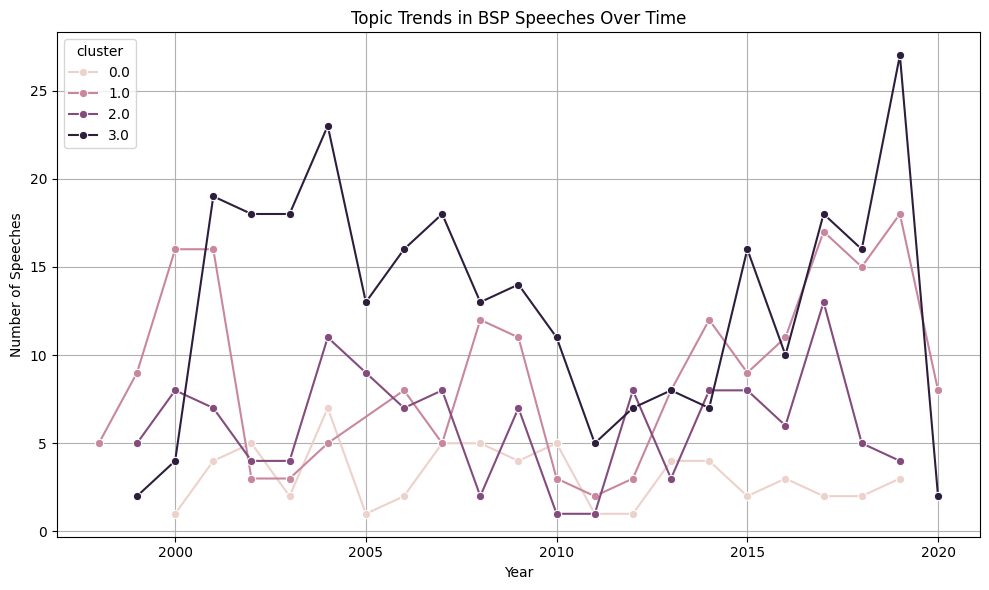

In [45]:
# Assigning cluster labels to the dataset
bsp.loc[bsp['Text'].notna(), 'cluster'] = kmeans.predict(tfidf_matrix)

# Visualize cluster trends over time
cluster_year_counts = bsp.groupby(['year', 'cluster']).size().reset_index(name='count')

plt.figure(figsize=(10,6))
sns.lineplot(data=cluster_year_counts, x='year', y='count', hue='cluster', marker='o')
plt.title('Topic Trends in BSP Speeches Over Time')
plt.ylabel('Number of Speeches')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
# Showing sample representative speeches by picking samples closest to each cluster center

from sklearn.metrics import pairwise_distances_argmin_min

closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, tfidf_matrix.toarray())

for i, idx in enumerate(closest):
    print(f"\nRepresentative speech for Cluster {i}:")
    print(bsp.iloc[idx]['Text'][:500])  # Preview first 500 chars


Representative speech for Cluster 0:
It is my pleasure to be invited to deliver this keynote speech in this 2 nd International Forum on Microfinance sponsored by INAFI Philippines. I welcome this opportunity to share with you the progress that we have achieved thus far in promoting microfinance in the banking sector. In year 2000, the BSP took up the challenge of promoting the development of sustainable microfinance. Since then we have focused on creating an enabling regulatory policy, supporting training and capacity building, dru

Representative speech for Cluster 1:
Introduction Mr. Horacio Cebrero III, President, Association Cambiste Internationale (ACI) Philippines--the Financial Markets Association; Mr. Roberto Juanchito Dispo, President, Money Market Association of the Philippines (MART); Ms. Ma. Elena Sarmiento, President, Trust Officers Association of the Philippines (TOAP); distinguished guests, ladies and gentlemen, good evening. I take great pleasure in speaking before the

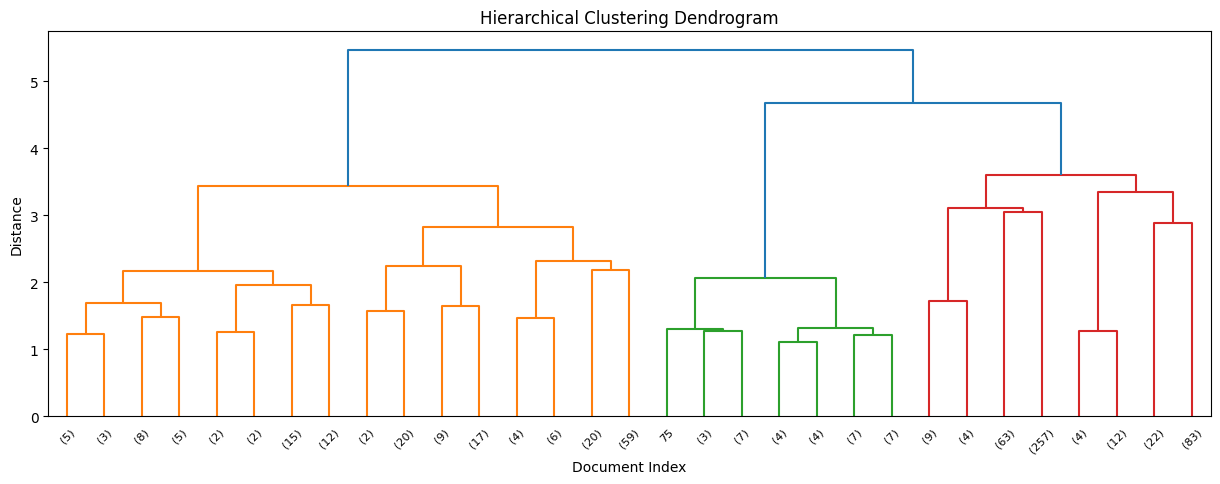

In [47]:
# Hierarchical Clustering
from scipy.spatial.distance import pdist
condensed_dist = pdist(tfidf_matrix.toarray(), 'euclidean')
linkage_matrix = linkage(condensed_dist, method='ward')
plt.figure(figsize=(15, 5))
dendrogram(linkage_matrix, truncate_mode='level', p=4)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Document Index")
plt.ylabel("Distance")
plt.show()

In [48]:
# LDA Topic Modeling
lda = LatentDirichletAllocation(n_components=8, random_state=123, max_iter=10, learning_method='batch')
lda.fit(tfidf_matrix)

LatentDirichletAllocation(n_components=8, random_state=123)

In [49]:
# Top words per topic
terms = vectorizer.get_feature_names_out()
topics = []
for idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[:-16:-1]]
    topics.append((f"Topic {idx+1}", ', '.join(top_terms)))

topics_df = pd.DataFrame(topics, columns=["Topic", "Top Words"])
topics_df

,Topic,Top Words
0,Topic 1,"araw, lamang, hindi, mahalagang, kung, ay, ito..."
1,Topic 2,"mahalagang, ctb, cma, bmap, araw, seacen, lama..."
2,Topic 3,"mahalagang, ctb, cma, bmap, araw, seacen, lama..."
3,Topic 4,"mahalagang, ctb, cma, bmap, araw, seacen, lama..."
4,Topic 5,"bmap, ctb, seacen, insolvency, marketable, asc..."
5,Topic 6,"financial, bsp, banking, banks, market, percen..."
6,Topic 7,"mahalagang, ctb, cma, bmap, araw, seacen, lama..."
7,Topic 8,"cma, microentrepreneurship, phenomenal, ahmed,..."
